In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2025-02-13 11:20:33.860445: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-13 11:20:33.866096: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-13 11:20:33.887060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739434833.925601   26664 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739434833.935441   26664 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-13 11:20:33.978149: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
# Load the clustered dataset directly
df = pd.read_csv('baringo_clustered_data.csv')

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4018 non-null   int64  
 1   temperature    4018 non-null   float64
 2   dew_point      4018 non-null   float64
 3   humidity       4018 non-null   float64
 4   wind_speed     4018 non-null   float64
 5   pressure       4018 non-null   float64
 6   precipitation  4018 non-null   float64
 7   region_id      4018 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 282.5 KB


In [3]:
df['7_day_cum_precip'] = df['precipitation'].rolling(window=7).sum()

# Normalize features (min-max scaling)
df['norm_precip'] = 1 - (df['7_day_cum_precip'] / df['7_day_cum_precip'].max())  # Inverse: lower precipitation → higher drought risk
df['norm_temp'] = df['temperature'] / df['temperature'].max()
df['norm_humidity'] = 1 - (df['humidity'] / df['humidity'].max())  # Inverse: lower humidity → higher drought risk
df['norm_pressure'] = df['pressure'] / df['pressure'].max()  # Higher pressure → more drought risk

# Weighted sum of features (tuned weights based on analysis)
df['drought_probability'] = (
    (df['norm_precip'] * 0.5) +  
    (df['norm_temp'] * 0.3) +  
    (df['norm_humidity'] * 0.15) +  
    (df['norm_pressure'] * 0.05)  
)

# Clip values to ensure probability range (0 to 1)
df['drought_probability'] = df['drought_probability'].clip(0, 1)

In [4]:
# Select features and target
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'drought_probability'

df.head()

,Unnamed: 0,temperature,dew_point,humidity,wind_speed,pressure,precipitation,region_id,7_day_cum_precip,norm_precip,norm_temp,norm_humidity,norm_pressure,drought_probability
time,,,,,,,,,,,,,,
2010-01-01,0,18.0,14.0,85.0,5.0,29.91,23.0,3,NaN,NaN,0.750000,0.132653,0.994018,NaN
2010-01-02,1,18.0,16.0,89.0,6.0,29.94,28.8,3,NaN,NaN,0.750000,0.091837,0.995015,NaN
2010-01-03,2,18.0,14.0,82.0,10.0,29.94,2.5,0,NaN,NaN,0.750000,0.163265,0.995015,NaN
2010-01-04,3,18.0,13.0,76.0,9.0,29.94,1.7,2,NaN,NaN,0.750000,0.224490,0.995015,NaN
2010-01-05,4,19.0,12.0,69.0,10.0,29.91,1.3,2,NaN,NaN,0.791667,0.295918,0.994018,NaN


In [5]:
# 🔹 Normalize input features (min-max scaling)
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [6]:
# 🔹 Prepare sequences for LSTM
sequence_length = 10  # Using last 10 days as input for prediction
X, y = [], []

for i in range(sequence_length, len(df)):
    X.append(df[features].iloc[i-sequence_length:i].values)
    y.append(df[target].iloc[i])

X, y = np.array(X), np.array(y)

# 🔹 Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


In [7]:
# 🔹 Build LSTM Model
model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True), input_shape=(sequence_length, len(features))),
    Dropout(0.4),
    Bidirectional(LSTM(50, return_sequences=False)),
    Dropout(0.4),
    Dense(30, activation='relu'),
    Dense(1, activation='sigmoid')  # Output is between 0 and 1
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(), metrics=['mae'])

# Train Model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)


2025-02-13 11:20:57.377230: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ronny/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - loss: 0.0128 - mae: 0.1242 - val_loss: 0.0016 - val_mae: 0.0400
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0016 - mae: 0.0432 - val_loss: 6.4477e-04 - val_mae: 0.0266
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 8.4120e-04 - mae: 0.0319 - val_loss: 4.8012e-04 - val_mae: 0.0213
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 6.8212e-04 - mae: 0.0282 - val_loss: 5.4031e-04 - val_mae: 0.0233
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 6.4768e-04 - mae: 0.0275 - val_loss: 4.3888e-04 - val_mae: 0.0213
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 5.5945e-04 - mae: 0.0261 - val_loss: 4.0855e-04 - val_mae: 0.0201
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 6.1170e-04 - mae: 0.0267 - val_loss: 4.3854e-04 - val_mae: 0.0217
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 5.2482e-04 - mae: 0.0246 - val_loss: 4.0085e-04 - val_mae: 0.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [9]:
# 🔹 Model Evaluation
y_pred = model.predict(X_test)

# Convert predictions back to original scale
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
RMSE: 0.02668844002400313
MAE: 0.01884561646736839
MSE: 0.0007122728309148121


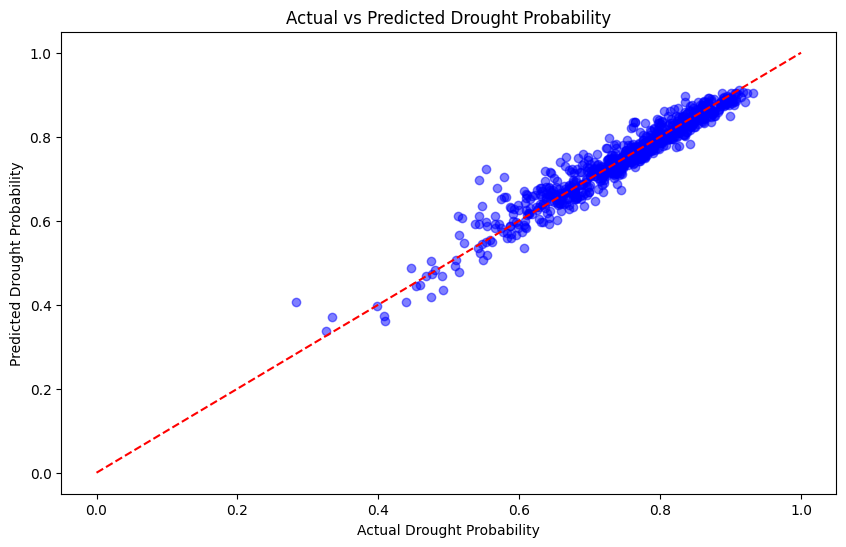

In [10]:
# 🔹 Plot Actual vs Predicted for ALL DATA
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Perfect prediction line
plt.xlabel("Actual Drought Probability")
plt.ylabel("Predicted Drought Probability")
plt.title("Actual vs Predicted Drought Probability")
plt.show()

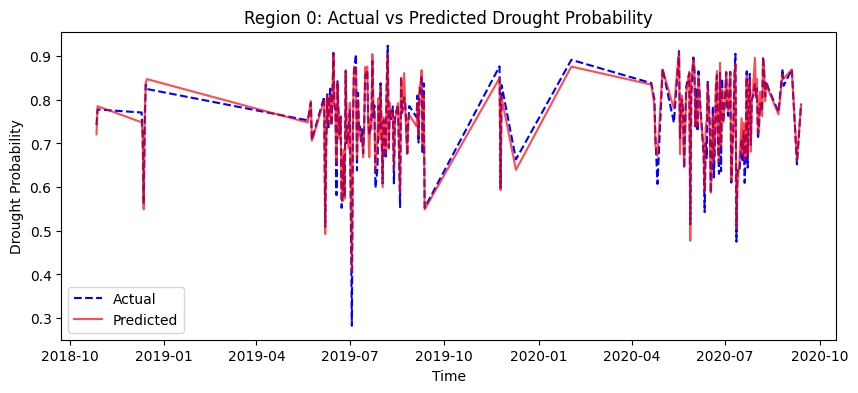

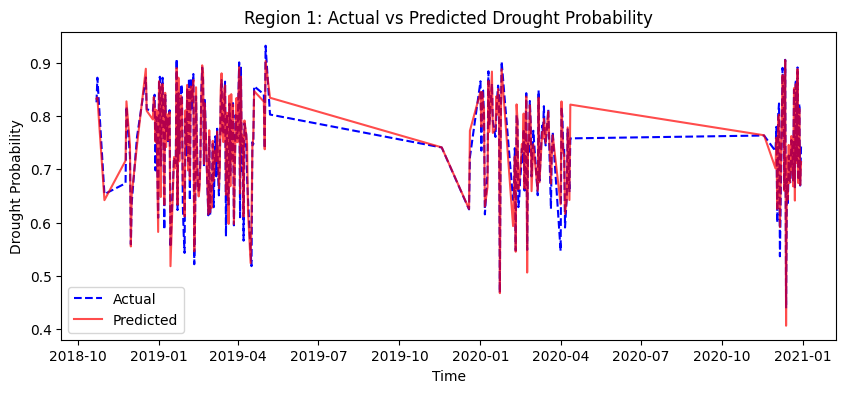

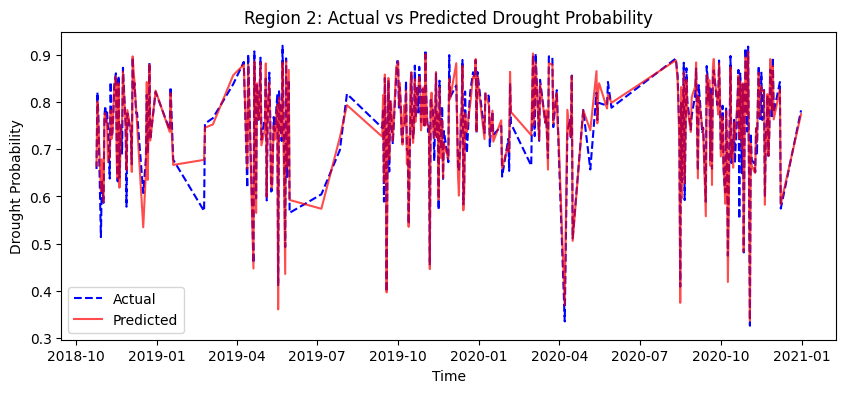

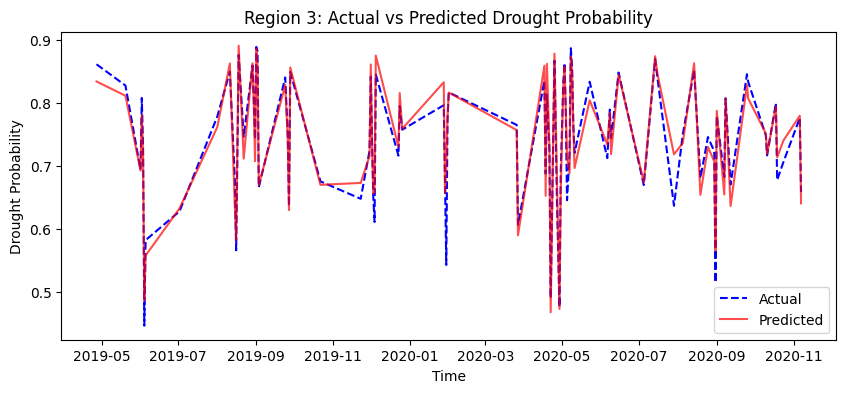

In [11]:
regions_test = df['region_id'].iloc[-len(y_test):].values  # Extract region IDs

regions_unique = np.unique(regions_test)  # Get unique regions

for region in regions_unique:
    plt.figure(figsize=(10, 4))
    
    mask = (regions_test == region)  # Filter data for each region
    
    plt.plot(df.index[-len(y_test):][mask], y_test[mask], linestyle='dashed', color='blue', label="Actual")
    plt.plot(df.index[-len(y_test):][mask], y_pred[mask], color='red', alpha=0.7, label="Predicted")
    
    plt.legend()
    plt.title(f"Region {region}: Actual vs Predicted Drought Probability")
    plt.xlabel("Time")
    plt.ylabel("Drought Probability")
    
    plt.show()


In [17]:
# Ensure y_test and y_pred are 1D arrays
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred).flatten()
regions_flat = np.array(regions_test).flatten()

# Convert predictions and actual values into a DataFrame for easy comparison
results_df = pd.DataFrame({
    "Date": df.index[-len(y_test_flat):],  # Match the test set length
    "Region": regions_flat,
    "Actual Drought Probability": y_test_flat,
    "Predicted Drought Probability": y_pred_flat
})

# Display a random sample of 10 rows
sample_results = results_df.sample(10, random_state=42)  # Set seed for reproducibility
print(sample_results)


          Date  Region  Actual Drought Probability  \
192 2019-05-02       1                    0.932099   
294 2019-08-12       0                    0.784638   
168 2019-04-08       1                    0.786327   
521 2020-03-26       3                    0.765164   
535 2020-04-09       1                    0.775258   
788 2020-12-18       1                    0.676197   
591 2020-06-04       0                    0.727556   
323 2019-09-10       0                    0.675645   
218 2019-05-28       2                    0.641020   
405 2019-12-01       3                    0.841761   

     Predicted Drought Probability  
192                       0.903270  
294                       0.771242  
168                       0.791623  
521                       0.756953  
535                       0.778745  
788                       0.691681  
591                       0.740187  
323                       0.696237  
218                       0.663461  
405                       0.861046 

In [18]:
# Filter cases where predicted drought probability is above 80%
high_risk_droughts = results_df[results_df["Predicted Drought Probability"] > 0.8]

# Display the high-risk cases
print(high_risk_droughts)


          Date  Region  Actual Drought Probability  \
0   2018-10-22       1                    0.825803   
1   2018-10-23       1                    0.872053   
3   2018-10-25       2                    0.821173   
22  2018-11-13       2                    0.831631   
23  2018-11-14       2                    0.849535   
..         ...     ...                         ...   
782 2020-12-12       1                    0.905656   
792 2020-12-22       1                    0.849234   
794 2020-12-24       1                    0.868074   
796 2020-12-26       1                    0.891330   
798 2020-12-28       1                    0.823034   

     Predicted Drought Probability  
0                         0.832494  
1                         0.835118  
3                         0.800944  
22                        0.822851  
23                        0.843825  
..                             ...  
782                       0.905246  
792                       0.852426  
794               